In [9]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (2).csv


In [10]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ==============================
# DOWNLOAD NLTK DATA
# ==============================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv("IMDB Dataset.csv")

print("Shape:", df.shape)
print(df.head())


# ==============================
# LABEL CONVERSION
# ==============================

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})


# ==============================
# NLP PREPROCESSING
# ==============================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['review'].apply(preprocess_text)


# ==============================
# TF-IDF FEATURES
# ==============================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']


# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# MODEL TRAINING
# ==============================

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


# ==============================
# EVALUATION
# ==============================

def evaluate(y_test, y_pred, name):
    print("\n===== ", name, " =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))


evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


# ==============================
# CONFUSION MATRIX
# ==============================

from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_lr))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

=====  Logistic Regression  =====
Accuracy : 0.888
Precision: 0.8793804453049371
Recall   : 0.9013693193093868
F1 Score : 0.8902391219129753

=====  Naive Bayes  =====
Accuracy : 0.8554
Precision: 0.8517720775406306
Recall   : 0.8632665211351459
F1 Score : 0.8574807806031933

=====  Decision Tree  =====
Accuracy : 0.721
Precision: 0.7250350210126075
Recall   : 0.7189918634649732
F1 Score : 0.7220007971303308

Confusion Matrix (Logistic Regression):
[[4338  623]
 [ 497 4542]]


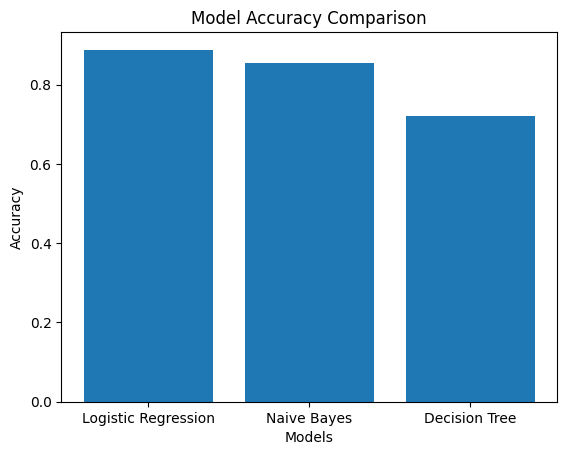

In [14]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

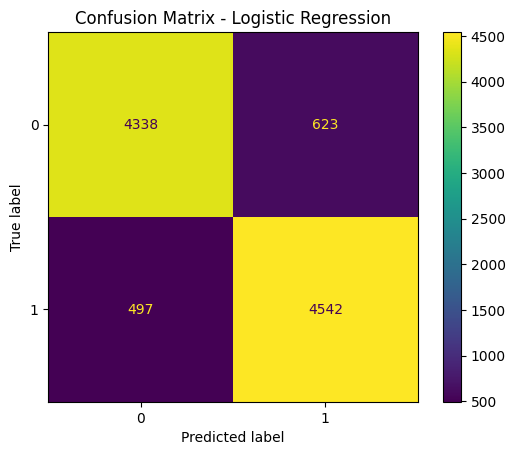

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

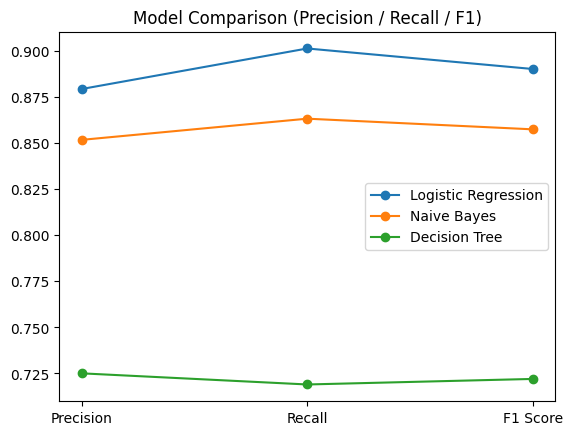

In [16]:
metrics = ['Precision', 'Recall', 'F1 Score']

lr_scores = [
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

nb_scores = [
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]

dt_scores = [
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

x = range(len(metrics))

plt.figure()
plt.plot(x, lr_scores, marker='o', label='Logistic Regression')
plt.plot(x, nb_scores, marker='o', label='Naive Bayes')
plt.plot(x, dt_scores, marker='o', label='Decision Tree')

plt.xticks(x, metrics)
plt.title("Model Comparison (Precision / Recall / F1)")
plt.legend()
plt.show()